# Restart Guide - Load Final SpendWise Model

After restarting the computer or Jupyter kernel, the ML model does not need to be retrained.

Run the following cells in order:

1. Load saved ML pipeline objects
2. Load the final SpendWise model
3. Define the backend-ready prediction function

The saved artifacts are located in:

ml_artifacts/

The final model is:

final_spendwise_model.pkl

After these cells are executed, the model is ready to generate predictions and can be integrated with the Flask backend.

So, after a restart, your practical sequence is:

① Cell 104 → load saved preprocessing/features

② Cell 124 → load final_spendwise_model.pkl

③ Cell 126 → define predict_next_month_expense()

④ Done → model is ready for backend use.

# SpendWise - ML Feature Engineering

This notebook prepares the SpendWise longitudinal dataset for machine learning.

The main objective is to create historical spending features and a future expense target that can be used to predict the user's next month's total Food, Travel, and Entertainment expenditure.

The target variable for the prediction task is:

Next_Month_Total_Expense

## Import Required Libraries

The required Python libraries are imported for data manipulation, numerical calculations, and dataset inspection.

In [7]:
import pandas as pd
import numpy as np

print("Libraries imported successfully.")

Libraries imported successfully.


## Load Longitudinal Dataset

The validated SpendWise longitudinal dataset is loaded.

This dataset contains 12 monthly records for each user from January 2025 to December 2025.

In [8]:
input_path = "spendwise_longitudinal_dataset.csv"

longitudinal_df = pd.read_csv(input_path)

longitudinal_df["Month"] = pd.to_datetime(
    longitudinal_df["Month"]
)

print("Dataset loaded successfully.")
print("Shape:", longitudinal_df.shape)

display(longitudinal_df.head())

Dataset loaded successfully.
Shape: (68472, 19)


,User_ID,Age,Occupation,City_Tier,Desired_Savings_Percentage,Desired_Savings,Month,Month_Number,Quarter,Income,Food_Expense,Travel_Expense,Entertainment_Expense,Total_Expense,Remaining_Income,Remaining_Income_Percentage,Food_Percentage,Travel_Percentage,Entertainment_Percentage
0,U00001,35,Student,Tier 3,13.997808,7050.360422,2025-01-01,1,Q1,51118.154153,7251.489712,2959.538900,1571.342825,11782.371437,39335.782715,76.950710,61.545248,25.118364,13.336388
1,U00001,35,Student,Tier 3,13.997808,7050.360422,2025-02-01,2,Q1,50259.001200,8103.568331,3395.485059,1788.395595,13287.448984,36971.552216,73.562051,60.986637,25.554078,13.459285
2,U00001,35,Student,Tier 3,13.997808,7050.360422,2025-03-01,3,Q1,51551.665821,7349.302806,3774.737040,1836.716315,12960.756161,38590.909661,74.858705,56.704275,29.124358,14.171367
3,U00001,35,Student,Tier 3,13.997808,7050.360422,2025-04-01,4,Q2,52984.959750,8248.640275,3456.150563,1777.494609,13482.285447,39502.674303,74.554505,61.181321,25.634753,13.183927
4,U00001,35,Student,Tier 3,13.997808,7050.360422,2025-05-01,5,Q2,50413.903084,7970.677730,3168.358214,1512.602949,12651.638892,37762.264192,74.904465,63.001148,25.043065,11.955787


## Verify Longitudinal Dataset

Before creating ML features, the dataset structure is verified to ensure that the correct longitudinal dataset has been loaded.

In [9]:
print("Number of rows:", len(longitudinal_df))
print("Number of columns:", len(longitudinal_df.columns))

print("\nUnique users:")
print(longitudinal_df["User_ID"].nunique())

print("\nDate range:")
print(
    longitudinal_df["Month"].min(),
    "to",
    longitudinal_df["Month"].max()
)

print("\nMissing values:")
print(longitudinal_df.isnull().sum().sum())

Number of rows: 68472
Number of columns: 19

Unique users:
5706

Date range:
2025-01-01 00:00:00 to 2025-12-01 00:00:00

Missing values:
0


## Sort Data by User and Month

The dataset is sorted by User_ID and Month.

This ensures that previous-month and next-month calculations are performed in the correct chronological order for each user.

In [10]:
longitudinal_df = (
    longitudinal_df
    .sort_values(
        ["User_ID", "Month"]
    )
    .reset_index(drop=True)
)

print("Dataset sorted successfully.")

display(
    longitudinal_df[
        [
            "User_ID",
            "Month",
            "Total_Expense"
        ]
    ].head(15)
)

Dataset sorted successfully.


,User_ID,Month,Total_Expense
0,U00001,2025-01-01,11782.371437
1,U00001,2025-02-01,13287.448984
2,U00001,2025-03-01,12960.756161
3,U00001,2025-04-01,13482.285447
4,U00001,2025-05-01,12651.638892
5,U00001,2025-06-01,12908.574244
6,U00001,2025-07-01,13252.749604
7,U00001,2025-08-01,12549.397093
8,U00001,2025-09-01,13612.334942
9,U00001,2025-10-01,13462.375667


## Create Next-Month Expense Target

The main prediction target is created by shifting Total_Expense by one month within each user.

For every monthly record, the target represents the user's actual total expense in the following month.

December records do not have a following month within the available dataset and will therefore have a missing target.

In [11]:
longitudinal_df["Next_Month_Total_Expense"] = (
    longitudinal_df
    .groupby("User_ID")["Total_Expense"]
    .shift(-1)
)

print("Next-month target created successfully.")

display(
    longitudinal_df[
        [
            "User_ID",
            "Month",
            "Total_Expense",
            "Next_Month_Total_Expense"
        ]
    ].head(15)
)

Next-month target created successfully.


,User_ID,Month,Total_Expense,Next_Month_Total_Expense
0,U00001,2025-01-01,11782.371437,13287.448984
1,U00001,2025-02-01,13287.448984,12960.756161
2,U00001,2025-03-01,12960.756161,13482.285447
3,U00001,2025-04-01,13482.285447,12651.638892
4,U00001,2025-05-01,12651.638892,12908.574244
5,U00001,2025-06-01,12908.574244,13252.749604
6,U00001,2025-07-01,13252.749604,12549.397093
7,U00001,2025-08-01,12549.397093,13612.334942
8,U00001,2025-09-01,13612.334942,13462.375667
9,U00001,2025-10-01,13462.375667,13663.072936


## Verify Next-Month Target

The target variable is checked to confirm that each user's monthly expense has been shifted correctly and that only the final month has no future target.

In [12]:
print("Total records:", len(longitudinal_df))

print(
    "\nRecords with target:",
    longitudinal_df["Next_Month_Total_Expense"].notnull().sum()
)

print(
    "Records without target:",
    longitudinal_df["Next_Month_Total_Expense"].isnull().sum()
)

print("\nTarget missing values by month:")

display(
    longitudinal_df
    .groupby("Month")["Next_Month_Total_Expense"]
    .apply(lambda x: x.isnull().sum())
)

Total records: 68472

Records with target: 62766
Records without target: 5706

Target missing values by month:


Month
2025-01-01       0
2025-02-01       0
2025-03-01       0
2025-04-01       0
2025-05-01       0
2025-06-01       0
2025-07-01       0
2025-08-01       0
2025-09-01       0
2025-10-01       0
2025-11-01       0
2025-12-01    5706
Name: Next_Month_Total_Expense, dtype: int64

## Create Previous-Month Expense Features

Historical spending features are created using previous monthly values for each user.

These lag features allow the ML model to learn from the user's recent spending behavior.

The following previous-month features will be created:

- Previous_Month_Total_Expense
- Previous_Month_Food_Expense
- Previous_Month_Travel_Expense
- Previous_Month_Entertainment_Expense

In [13]:
longitudinal_df["Previous_Month_Total_Expense"] = (
    longitudinal_df
    .groupby("User_ID")["Total_Expense"]
    .shift(1)
)

longitudinal_df["Previous_Month_Food_Expense"] = (
    longitudinal_df
    .groupby("User_ID")["Food_Expense"]
    .shift(1)
)

longitudinal_df["Previous_Month_Travel_Expense"] = (
    longitudinal_df
    .groupby("User_ID")["Travel_Expense"]
    .shift(1)
)

longitudinal_df["Previous_Month_Entertainment_Expense"] = (
    longitudinal_df
    .groupby("User_ID")["Entertainment_Expense"]
    .shift(1)
)

print("Previous-month features created successfully.")

display(
    longitudinal_df[
        [
            "User_ID",
            "Month",
            "Total_Expense",
            "Previous_Month_Total_Expense",
            "Previous_Month_Food_Expense",
            "Previous_Month_Travel_Expense",
            "Previous_Month_Entertainment_Expense"
        ]
    ].head(15)
)

Previous-month features created successfully.


,User_ID,Month,Total_Expense,Previous_Month_Total_Expense,Previous_Month_Food_Expense,Previous_Month_Travel_Expense,Previous_Month_Entertainment_Expense
0,U00001,2025-01-01,11782.371437,NaN,NaN,NaN,NaN
1,U00001,2025-02-01,13287.448984,11782.371437,7251.489712,2959.538900,1571.342825
2,U00001,2025-03-01,12960.756161,13287.448984,8103.568331,3395.485059,1788.395595
3,U00001,2025-04-01,13482.285447,12960.756161,7349.302806,3774.737040,1836.716315
4,U00001,2025-05-01,12651.638892,13482.285447,8248.640275,3456.150563,1777.494609
5,U00001,2025-06-01,12908.574244,12651.638892,7970.677730,3168.358214,1512.602949
6,U00001,2025-07-01,13252.749604,12908.574244,7701.617573,3623.076110,1583.880561
7,U00001,2025-08-01,12549.397093,13252.749604,8635.917018,2962.844434,1653.988152
8,U00001,2025-09-01,13612.334942,12549.397093,7985.623806,2933.883487,1629.889800
9,U00001,2025-10-01,13462.375667,13612.334942,8468.472742,3446.852726,1697.009474


## Create 2-Month and 3-Month Lag Features

Additional lag features are created to capture slightly longer-term spending behavior.

These features represent:

- Spending two months ago
- Spending three months ago

They help the model identify whether a user's spending pattern is stable, increasing, or decreasing over time.

In [14]:
longitudinal_df["Expense_Lag_2"] = (
    longitudinal_df
    .groupby("User_ID")["Total_Expense"]
    .shift(2)
)

longitudinal_df["Expense_Lag_3"] = (
    longitudinal_df
    .groupby("User_ID")["Total_Expense"]
    .shift(3)
)

print("2-month and 3-month lag features created successfully.")

display(
    longitudinal_df[
        [
            "User_ID",
            "Month",
            "Total_Expense",
            "Expense_Lag_2",
            "Expense_Lag_3"
        ]
    ].head(15)
)

2-month and 3-month lag features created successfully.


,User_ID,Month,Total_Expense,Expense_Lag_2,Expense_Lag_3
0,U00001,2025-01-01,11782.371437,NaN,NaN
1,U00001,2025-02-01,13287.448984,NaN,NaN
2,U00001,2025-03-01,12960.756161,11782.371437,NaN
3,U00001,2025-04-01,13482.285447,13287.448984,11782.371437
4,U00001,2025-05-01,12651.638892,12960.756161,13287.448984
5,U00001,2025-06-01,12908.574244,13482.285447,12960.756161
6,U00001,2025-07-01,13252.749604,12651.638892,13482.285447
7,U00001,2025-08-01,12549.397093,12908.574244,12651.638892
8,U00001,2025-09-01,13612.334942,13252.749604,12908.574244
9,U00001,2025-10-01,13462.375667,12549.397093,13252.749604


## Create Historical Rolling Average Features

Historical rolling averages are calculated to capture the user's recent spending trend.

A three-month rolling average is calculated using only months before the current month.

This prevents information from the current or future target period from leaking into the ML features.

In [15]:
longitudinal_df["Rolling_3_Month_Avg_Expense"] = (
    longitudinal_df
    .groupby("User_ID")["Total_Expense"]
    .transform(
        lambda x: x.shift(1).rolling(
            window=3,
            min_periods=1
        ).mean()
    )
)

print("Rolling average feature created successfully.")

display(
    longitudinal_df[
        [
            "User_ID",
            "Month",
            "Total_Expense",
            "Previous_Month_Total_Expense",
            "Rolling_3_Month_Avg_Expense"
        ]
    ].head(15)
)

Rolling average feature created successfully.


,User_ID,Month,Total_Expense,Previous_Month_Total_Expense,Rolling_3_Month_Avg_Expense
0,U00001,2025-01-01,11782.371437,NaN,NaN
1,U00001,2025-02-01,13287.448984,11782.371437,11782.371437
2,U00001,2025-03-01,12960.756161,13287.448984,12534.910211
3,U00001,2025-04-01,13482.285447,12960.756161,12676.858861
4,U00001,2025-05-01,12651.638892,13482.285447,13243.496864
5,U00001,2025-06-01,12908.574244,12651.638892,13031.560167
6,U00001,2025-07-01,13252.749604,12908.574244,13014.166194
7,U00001,2025-08-01,12549.397093,13252.749604,12937.654247
8,U00001,2025-09-01,13612.334942,12549.397093,12903.573647
9,U00001,2025-10-01,13462.375667,13612.334942,13138.160546


## Create Monthly Spending Change

The change in total expense from the previous month is calculated.

This feature helps the model identify whether spending is increasing or decreasing.

In [16]:
longitudinal_df["Monthly_Expense_Change"] = (
    longitudinal_df["Previous_Month_Total_Expense"]
    - longitudinal_df["Expense_Lag_2"]
)

print("Monthly expense change feature created successfully.")

display(
    longitudinal_df[
        [
            "User_ID",
            "Month",
            "Expense_Lag_2",
            "Previous_Month_Total_Expense",
            "Monthly_Expense_Change"
        ]
    ].head(15)
)

Monthly expense change feature created successfully.


,User_ID,Month,Expense_Lag_2,Previous_Month_Total_Expense,Monthly_Expense_Change
0,U00001,2025-01-01,NaN,NaN,NaN
1,U00001,2025-02-01,NaN,11782.371437,NaN
2,U00001,2025-03-01,11782.371437,13287.448984,1505.077547
3,U00001,2025-04-01,13287.448984,12960.756161,-326.692823
4,U00001,2025-05-01,12960.756161,13482.285447,521.529287
5,U00001,2025-06-01,13482.285447,12651.638892,-830.646555
6,U00001,2025-07-01,12651.638892,12908.574244,256.935351
7,U00001,2025-08-01,12908.574244,13252.749604,344.175361
8,U00001,2025-09-01,13252.749604,12549.397093,-703.352511
9,U00001,2025-10-01,12549.397093,13612.334942,1062.937849


## Verify Historical Features

The newly created historical features are inspected to ensure that the lag and rolling calculations follow the correct chronological order.

In [17]:
feature_columns = [
    "Previous_Month_Total_Expense",
    "Previous_Month_Food_Expense",
    "Previous_Month_Travel_Expense",
    "Previous_Month_Entertainment_Expense",
    "Expense_Lag_2",
    "Expense_Lag_3",
    "Rolling_3_Month_Avg_Expense",
    "Monthly_Expense_Change"
]

print("Historical feature summary:")

display(
    longitudinal_df[feature_columns]
    .describe()
    .round(2)
)

Historical feature summary:


,Previous_Month_Total_Expense,Previous_Month_Food_Expense,Previous_Month_Travel_Expense,Previous_Month_Entertainment_Expense,Expense_Lag_2,Expense_Lag_3,Rolling_3_Month_Avg_Expense,Monthly_Expense_Change
count,62766.00,62766.00,62766.00,62766.00,57060.00,51354.00,62766.00,57060.00
mean,11158.58,6854.48,2807.22,1496.88,11115.72,11081.40,11103.15,62.91
std,11484.19,6977.49,3042.37,1635.80,11441.64,11404.78,11423.18,894.40
min,362.27,205.32,88.36,43.70,362.27,362.27,377.34,-17431.84
25%,4539.26,2765.42,1123.33,578.88,4522.86,4507.30,4532.10,-224.76
50%,7898.06,4846.91,1962.65,1033.16,7868.49,7838.07,7868.95,32.80
75%,13763.98,8471.01,3419.83,1837.92,13705.33,13671.39,13687.65,323.74
max,289665.45,162007.07,94416.82,44773.21,284429.90,284429.90,277221.03,18477.00


## Create Previous-Month Spending Pattern Features

Previous-month spending percentages are created to capture changes in the user's spending pattern.

These features represent the proportion of the previous month's total expense spent on:

- Food
- Travel
- Entertainment

In [18]:
longitudinal_df["Previous_Month_Food_Percentage"] = (
    longitudinal_df
    .groupby("User_ID")["Food_Percentage"]
    .shift(1)
)

longitudinal_df["Previous_Month_Travel_Percentage"] = (
    longitudinal_df
    .groupby("User_ID")["Travel_Percentage"]
    .shift(1)
)

longitudinal_df["Previous_Month_Entertainment_Percentage"] = (
    longitudinal_df
    .groupby("User_ID")["Entertainment_Percentage"]
    .shift(1)
)

print("Previous-month spending pattern features created successfully.")

display(
    longitudinal_df[
        [
            "User_ID",
            "Month",
            "Food_Percentage",
            "Previous_Month_Food_Percentage",
            "Travel_Percentage",
            "Previous_Month_Travel_Percentage",
            "Entertainment_Percentage",
            "Previous_Month_Entertainment_Percentage"
        ]
    ].head(15)
)

Previous-month spending pattern features created successfully.


,User_ID,Month,Food_Percentage,Previous_Month_Food_Percentage,Travel_Percentage,Previous_Month_Travel_Percentage,Entertainment_Percentage,Previous_Month_Entertainment_Percentage
0,U00001,2025-01-01,61.545248,NaN,25.118364,NaN,13.336388,NaN
1,U00001,2025-02-01,60.986637,61.545248,25.554078,25.118364,13.459285,13.336388
2,U00001,2025-03-01,56.704275,60.986637,29.124358,25.554078,14.171367,13.459285
3,U00001,2025-04-01,61.181321,56.704275,25.634753,29.124358,13.183927,14.171367
4,U00001,2025-05-01,63.001148,61.181321,25.043065,25.634753,11.955787,13.183927
5,U00001,2025-06-01,59.662806,63.001148,28.067206,25.043065,12.269988,11.955787
6,U00001,2025-07-01,65.163210,59.662806,22.356451,28.067206,12.480340,12.269988
7,U00001,2025-08-01,63.633526,65.163210,23.378681,22.356451,12.987794,12.480340
8,U00001,2025-09-01,62.211757,63.633526,25.321539,23.378681,12.466704,12.987794
9,U00001,2025-10-01,61.773536,62.211757,24.368005,25.321539,13.858459,12.466704


## Create Previous-Month Remaining Income Features

Previous-month remaining income information is created to capture the user's recent financial position.

These features represent:

- Previous month's remaining income
- Previous month's remaining income percentage

In [19]:
longitudinal_df["Previous_Month_Remaining_Income"] = (
    longitudinal_df
    .groupby("User_ID")["Remaining_Income"]
    .shift(1)
)

longitudinal_df["Previous_Month_Remaining_Income_Percentage"] = (
    longitudinal_df
    .groupby("User_ID")["Remaining_Income_Percentage"]
    .shift(1)
)

print("Previous-month remaining income features created successfully.")

display(
    longitudinal_df[
        [
            "User_ID",
            "Month",
            "Remaining_Income",
            "Previous_Month_Remaining_Income",
            "Remaining_Income_Percentage",
            "Previous_Month_Remaining_Income_Percentage"
        ]
    ].head(15)
)

Previous-month remaining income features created successfully.


,User_ID,Month,Remaining_Income,Previous_Month_Remaining_Income,Remaining_Income_Percentage,Previous_Month_Remaining_Income_Percentage
0,U00001,2025-01-01,39335.782715,NaN,76.950710,NaN
1,U00001,2025-02-01,36971.552216,39335.782715,73.562051,76.950710
2,U00001,2025-03-01,38590.909661,36971.552216,74.858705,73.562051
3,U00001,2025-04-01,39502.674303,38590.909661,74.554505,74.858705
4,U00001,2025-05-01,37762.264192,39502.674303,74.904465,74.554505
5,U00001,2025-06-01,37605.381482,37762.264192,74.445529,74.904465
6,U00001,2025-07-01,40134.136584,37605.381482,75.176021,74.445529
7,U00001,2025-08-01,39699.204560,40134.136584,75.981372,75.176021
8,U00001,2025-09-01,36840.412584,39699.204560,73.019636,75.981372
9,U00001,2025-10-01,38646.426631,36840.412584,74.164872,73.019636


## Create Previous-Month Income Feature

The previous month's income is created to capture recent income behavior.

This feature can help the model understand whether the user's available income is relatively stable or changing over time.

In [20]:
longitudinal_df["Previous_Month_Income"] = (
    longitudinal_df
    .groupby("User_ID")["Income"]
    .shift(1)
)

print("Previous-month income feature created successfully.")

display(
    longitudinal_df[
        [
            "User_ID",
            "Month",
            "Income",
            "Previous_Month_Income"
        ]
    ].head(15)
)

Previous-month income feature created successfully.


,User_ID,Month,Income,Previous_Month_Income
0,U00001,2025-01-01,51118.154153,NaN
1,U00001,2025-02-01,50259.001200,51118.154153
2,U00001,2025-03-01,51551.665821,50259.001200
3,U00001,2025-04-01,52984.959750,51551.665821
4,U00001,2025-05-01,50413.903084,52984.959750
5,U00001,2025-06-01,50513.955726,50413.903084
6,U00001,2025-07-01,53386.886188,50513.955726
7,U00001,2025-08-01,52248.601652,53386.886188
8,U00001,2025-09-01,50452.747527,52248.601652
9,U00001,2025-10-01,52108.802298,50452.747527


## Create Monthly Income Change

The change between the current month's income and the previous month's income is calculated.

This feature can help identify whether the user's income is increasing or decreasing.

In [21]:
longitudinal_df["Monthly_Income_Change"] = (
    longitudinal_df["Income"]
    - longitudinal_df["Previous_Month_Income"]
)

print("Monthly income change feature created successfully.")

display(
    longitudinal_df[
        [
            "User_ID",
            "Month",
            "Previous_Month_Income",
            "Income",
            "Monthly_Income_Change"
        ]
    ].head(15)
)

Monthly income change feature created successfully.


,User_ID,Month,Previous_Month_Income,Income,Monthly_Income_Change
0,U00001,2025-01-01,NaN,51118.154153,NaN
1,U00001,2025-02-01,51118.154153,50259.001200,-859.152953
2,U00001,2025-03-01,50259.001200,51551.665821,1292.664622
3,U00001,2025-04-01,51551.665821,52984.959750,1433.293929
4,U00001,2025-05-01,52984.959750,50413.903084,-2571.056666
5,U00001,2025-06-01,50413.903084,50513.955726,100.052641
6,U00001,2025-07-01,50513.955726,53386.886188,2872.930462
7,U00001,2025-08-01,53386.886188,52248.601652,-1138.284535
8,U00001,2025-09-01,52248.601652,50452.747527,-1795.854126
9,U00001,2025-10-01,50452.747527,52108.802298,1656.054772


## Review Engineered Features

All historical and trend-based features created so far are reviewed before preparing the final ML dataset.

In [22]:
engineered_features = [
    "Previous_Month_Total_Expense",
    "Previous_Month_Food_Expense",
    "Previous_Month_Travel_Expense",
    "Previous_Month_Entertainment_Expense",
    "Expense_Lag_2",
    "Expense_Lag_3",
    "Rolling_3_Month_Avg_Expense",
    "Monthly_Expense_Change",
    "Previous_Month_Food_Percentage",
    "Previous_Month_Travel_Percentage",
    "Previous_Month_Entertainment_Percentage",
    "Previous_Month_Remaining_Income",
    "Previous_Month_Remaining_Income_Percentage",
    "Previous_Month_Income",
    "Monthly_Income_Change"
]

print("Number of engineered features:", len(engineered_features))

print("\nEngineered features:")
for feature in engineered_features:
    print("-", feature)

Number of engineered features: 15

Engineered features:
- Previous_Month_Total_Expense
- Previous_Month_Food_Expense
- Previous_Month_Travel_Expense
- Previous_Month_Entertainment_Expense
- Expense_Lag_2
- Expense_Lag_3
- Rolling_3_Month_Avg_Expense
- Monthly_Expense_Change
- Previous_Month_Food_Percentage
- Previous_Month_Travel_Percentage
- Previous_Month_Entertainment_Percentage
- Previous_Month_Remaining_Income
- Previous_Month_Remaining_Income_Percentage
- Previous_Month_Income
- Monthly_Income_Change


## Check Missing Values in Historical Features

The missing values introduced by lag and rolling calculations are inspected.

These missing values are expected because the first few months of each user's history do not have enough previous records.

In [23]:
missing_feature_values = (
    longitudinal_df[engineered_features]
    .isnull()
    .sum()
)

display(
    missing_feature_values[
        missing_feature_values > 0
    ]
)

Previous_Month_Total_Expense                   5706
Previous_Month_Food_Expense                    5706
Previous_Month_Travel_Expense                  5706
Previous_Month_Entertainment_Expense           5706
Expense_Lag_2                                 11412
Expense_Lag_3                                 17118
Rolling_3_Month_Avg_Expense                    5706
Monthly_Expense_Change                        11412
Previous_Month_Food_Percentage                 5706
Previous_Month_Travel_Percentage               5706
Previous_Month_Entertainment_Percentage        5706
Previous_Month_Remaining_Income                5706
Previous_Month_Remaining_Income_Percentage     5706
Previous_Month_Income                          5706
Monthly_Income_Change                          5706
dtype: int64

## Create ML-Ready Dataset

The ML dataset is created using records that have:

- A valid next-month target
- Three months of historical spending information

The first three months of each user's history are excluded because they do not contain enough historical information for the lag-based features.

December is also excluded because there is no next-month target within the available 2025 dataset.

In [24]:
ml_df = longitudinal_df[
    longitudinal_df["Next_Month_Total_Expense"].notnull()
].copy()

ml_df = ml_df[
    ml_df["Expense_Lag_3"].notnull()
].copy()

ml_df = ml_df.reset_index(drop=True)

print("ML dataset created successfully.")
print("Shape:", ml_df.shape)

display(
    ml_df.head()
)

ML dataset created successfully.
Shape: (45648, 35)


,User_ID,Age,Occupation,City_Tier,Desired_Savings_Percentage,Desired_Savings,Month,Month_Number,Quarter,Income,...,Expense_Lag_3,Rolling_3_Month_Avg_Expense,Monthly_Expense_Change,Previous_Month_Food_Percentage,Previous_Month_Travel_Percentage,Previous_Month_Entertainment_Percentage,Previous_Month_Remaining_Income,Previous_Month_Remaining_Income_Percentage,Previous_Month_Income,Monthly_Income_Change
0,U00001,35,Student,Tier 3,13.997808,7050.360422,2025-04-01,4,Q2,52984.959750,...,11782.371437,12676.858861,-326.692823,56.704275,29.124358,14.171367,38590.909661,74.858705,51551.665821,1433.293929
1,U00001,35,Student,Tier 3,13.997808,7050.360422,2025-05-01,5,Q2,50413.903084,...,13287.448984,13243.496864,521.529287,61.181321,25.634753,13.183927,39502.674303,74.554505,52984.959750,-2571.056666
2,U00001,35,Student,Tier 3,13.997808,7050.360422,2025-06-01,6,Q2,50513.955726,...,12960.756161,13031.560167,-830.646555,63.001148,25.043065,11.955787,37762.264192,74.904465,50413.903084,100.052641
3,U00001,35,Student,Tier 3,13.997808,7050.360422,2025-07-01,7,Q3,53386.886188,...,13482.285447,13014.166194,256.935351,59.662806,28.067206,12.269988,37605.381482,74.445529,50513.955726,2872.930462
4,U00001,35,Student,Tier 3,13.997808,7050.360422,2025-08-01,8,Q3,52248.601652,...,12651.638892,12937.654247,344.175361,65.163210,22.356451,12.480340,40134.136584,75.176021,53386.886188,-1138.284535


## Validate ML Dataset

The ML-ready dataset is checked for missing values, duplicate records, valid target values, and the number of records available for each user.

This ensures that the dataset is suitable for the next stage of feature selection and model preparation.

In [25]:
# ============================================================
# ML DATASET VALIDATION
# ============================================================

print("=" * 70)
print("ML DATASET VALIDATION")
print("=" * 70)

# Shape
print("\nShape:")
print(ml_df.shape)

# Unique users
print("\nUnique users:")
print(ml_df["User_ID"].nunique())

# Missing values
print("\nTotal missing values:")
print(ml_df.isnull().sum().sum())

# Missing values by column
print("\nMissing values by column:")
missing_values = ml_df.isnull().sum()

display(
    missing_values[
        missing_values > 0
    ]
)

# Duplicate User_ID + Month records
duplicate_records = (
    ml_df
    .duplicated(
        subset=["User_ID", "Month"]
    )
    .sum()
)

print(
    "\nDuplicate User_ID + Month records:",
    duplicate_records
)

# Target validation
print("\nTarget statistics:")

display(
    ml_df["Next_Month_Total_Expense"]
    .describe()
    .round(2)
)

# Target negative values
negative_targets = (
    ml_df["Next_Month_Total_Expense"] < 0
).sum()

print(
    "\nNegative target values:",
    negative_targets
)

# Records per user
print("\nRecords per user:")

display(
    ml_df
    .groupby("User_ID")
    .size()
    .value_counts()
    .sort_index()
)

print("=" * 70)

ML DATASET VALIDATION

Shape:
(45648, 35)

Unique users:
5706

Total missing values:
0

Missing values by column:


Series([], dtype: int64)


Duplicate User_ID + Month records: 0

Target statistics:


count     45648.00
mean      11369.23
std       11691.11
min         380.52
25%        4629.69
50%        8042.05
75%       14017.41
max      289665.45
Name: Next_Month_Total_Expense, dtype: float64


Negative target values: 0

Records per user:


8    5706
Name: count, dtype: int64

## Identify ML Features and Target

The ML-ready dataset contains user information, current-month financial information, historical spending features, and the next-month expense target.

The target variable is:

Next_Month_Total_Expense

User_ID is used only to identify users and is not provided to the ML model.

In [26]:
target_column = "Next_Month_Total_Expense"

id_columns = [
    "User_ID"
]

feature_columns = [
    column
    for column in ml_df.columns
    if column not in id_columns + [target_column]
]

print("Number of feature columns:", len(feature_columns))

print("\nFeature columns:")
for column in feature_columns:
    print("-", column)

print("\nTarget column:")
print(target_column)

Number of feature columns: 33

Feature columns:
- Age
- Occupation
- City_Tier
- Desired_Savings_Percentage
- Desired_Savings
- Month
- Month_Number
- Quarter
- Income
- Food_Expense
- Travel_Expense
- Entertainment_Expense
- Total_Expense
- Remaining_Income
- Remaining_Income_Percentage
- Food_Percentage
- Travel_Percentage
- Entertainment_Percentage
- Previous_Month_Total_Expense
- Previous_Month_Food_Expense
- Previous_Month_Travel_Expense
- Previous_Month_Entertainment_Expense
- Expense_Lag_2
- Expense_Lag_3
- Rolling_3_Month_Avg_Expense
- Monthly_Expense_Change
- Previous_Month_Food_Percentage
- Previous_Month_Travel_Percentage
- Previous_Month_Entertainment_Percentage
- Previous_Month_Remaining_Income
- Previous_Month_Remaining_Income_Percentage
- Previous_Month_Income
- Monthly_Income_Change

Target column:
Next_Month_Total_Expense


## Check for Data Leakage

The feature set is checked to ensure that the prediction target and future-month information are not accidentally included as model inputs.

Historical lag and rolling features are based only on information available before the prediction target month.

In [27]:
print("=" * 70)
print("DATA LEAKAGE CHECK")
print("=" * 70)

print("\nTarget column:")
print(target_column)

print("\nIs target included in features?")
print(target_column in feature_columns)

print("\nIs User_ID included in features?")
print("User_ID" in feature_columns)

print("\nFeatures containing 'Next_Month':")

future_features = [
    column
    for column in feature_columns
    if "Next_Month" in column
]

print(future_features)

DATA LEAKAGE CHECK

Target column:
Next_Month_Total_Expense

Is target included in features?
False

Is User_ID included in features?
False

Features containing 'Next_Month':
[]


## Review ML Features

The selected features are grouped into user profile, current-month financial, historical, and trend-based information.

This helps verify that the model inputs represent information that could realistically be available when making a next-month prediction.

In [28]:
feature_groups = {
    "User Profile": [
        "Age",
        "Occupation",
        "City_Tier"
    ],

    "Financial Goals": [
        "Desired_Savings_Percentage",
        "Desired_Savings"
    ],

    "Current Month Financial": [
        "Income",
        "Food_Expense",
        "Travel_Expense",
        "Entertainment_Expense",
        "Total_Expense",
        "Remaining_Income",
        "Remaining_Income_Percentage",
        "Food_Percentage",
        "Travel_Percentage",
        "Entertainment_Percentage"
    ],

    "Historical Features": [
        "Previous_Month_Total_Expense",
        "Previous_Month_Food_Expense",
        "Previous_Month_Travel_Expense",
        "Previous_Month_Entertainment_Expense",
        "Expense_Lag_2",
        "Expense_Lag_3",
        "Rolling_3_Month_Avg_Expense",
        "Previous_Month_Food_Percentage",
        "Previous_Month_Travel_Percentage",
        "Previous_Month_Entertainment_Percentage",
        "Previous_Month_Remaining_Income",
        "Previous_Month_Remaining_Income_Percentage",
        "Previous_Month_Income"
    ],

    "Trend Features": [
        "Monthly_Expense_Change",
        "Monthly_Income_Change"
    ],

    "Time Features": [
        "Month",
        "Month_Number",
        "Quarter"
    ]
}

for group, columns in feature_groups.items():
    print("\n" + "=" * 50)
    print(group)
    print("=" * 50)

    for column in columns:
        print("-", column)


User Profile
- Age
- Occupation
- City_Tier

Financial Goals
- Desired_Savings_Percentage
- Desired_Savings

Current Month Financial
- Income
- Food_Expense
- Travel_Expense
- Entertainment_Expense
- Total_Expense
- Remaining_Income
- Remaining_Income_Percentage
- Food_Percentage
- Travel_Percentage
- Entertainment_Percentage

Historical Features
- Previous_Month_Total_Expense
- Previous_Month_Food_Expense
- Previous_Month_Travel_Expense
- Previous_Month_Entertainment_Expense
- Expense_Lag_2
- Expense_Lag_3
- Rolling_3_Month_Avg_Expense
- Previous_Month_Food_Percentage
- Previous_Month_Travel_Percentage
- Previous_Month_Entertainment_Percentage
- Previous_Month_Remaining_Income
- Previous_Month_Remaining_Income_Percentage
- Previous_Month_Income

Trend Features
- Monthly_Expense_Change
- Monthly_Income_Change

Time Features
- Month
- Month_Number
- Quarter


## Final Feature Selection

The ML model should use only features that are meaningful and available at the time of prediction.

User_ID is excluded because it is only an identifier.

Month is excluded as a raw datetime column because Month_Number and Quarter already provide the required time information in a simpler numerical form.

The target variable Next_Month_Total_Expense is kept separately and is not used as an input feature.

The remaining features are retained because they describe the user's profile, financial goals, current-month spending, historical spending behavior, and spending/income trends.

In [29]:
selected_features = [
    "Age",
    "Occupation",
    "City_Tier",
    "Desired_Savings_Percentage",
    "Desired_Savings",

    "Month_Number",

    "Income",
    "Food_Expense",
    "Travel_Expense",
    "Entertainment_Expense",
    "Total_Expense",
    "Remaining_Income",
    "Remaining_Income_Percentage",
    "Food_Percentage",
    "Travel_Percentage",
    "Entertainment_Percentage",

    "Previous_Month_Total_Expense",
    "Previous_Month_Food_Expense",
    "Previous_Month_Travel_Expense",
    "Previous_Month_Entertainment_Expense",
    "Expense_Lag_2",
    "Expense_Lag_3",
    "Rolling_3_Month_Avg_Expense",
    "Monthly_Expense_Change",

    "Previous_Month_Food_Percentage",
    "Previous_Month_Travel_Percentage",
    "Previous_Month_Entertainment_Percentage",

    "Previous_Month_Remaining_Income",
    "Previous_Month_Remaining_Income_Percentage",

    "Previous_Month_Income",
    "Monthly_Income_Change"
]

target_column = "Next_Month_Total_Expense"

X = ml_df[selected_features].copy()
y = ml_df[target_column].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nNumber of selected features:", len(selected_features))

print("\nSelected features:")
for feature in selected_features:
    print("-", feature)

print("\nTarget:")
print("-", target_column)

Feature matrix shape: (45648, 31)
Target shape: (45648,)

Number of selected features: 31

Selected features:
- Age
- Occupation
- City_Tier
- Desired_Savings_Percentage
- Desired_Savings
- Month_Number
- Income
- Food_Expense
- Travel_Expense
- Entertainment_Expense
- Total_Expense
- Remaining_Income
- Remaining_Income_Percentage
- Food_Percentage
- Travel_Percentage
- Entertainment_Percentage
- Previous_Month_Total_Expense
- Previous_Month_Food_Expense
- Previous_Month_Travel_Expense
- Previous_Month_Entertainment_Expense
- Expense_Lag_2
- Expense_Lag_3
- Rolling_3_Month_Avg_Expense
- Monthly_Expense_Change
- Previous_Month_Food_Percentage
- Previous_Month_Travel_Percentage
- Previous_Month_Entertainment_Percentage
- Previous_Month_Remaining_Income
- Previous_Month_Remaining_Income_Percentage
- Previous_Month_Income
- Monthly_Income_Change

Target:
- Next_Month_Total_Expense


## Check Feature Data Types

The model cannot directly use categorical text values such as Occupation and City_Tier.

First, we identify numerical and categorical features.

Categorical features will be encoded in the next preprocessing step.

In [30]:
print("=" * 70)
print("FEATURE DATA TYPES")
print("=" * 70)

print(X.dtypes)

print("\nCategorical features:")
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

for feature in categorical_features:
    print("-", feature)

print("\nNumerical features:")
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

for feature in numerical_features:
    print("-", feature)

print("\nNumber of categorical features:", len(categorical_features))
print("Number of numerical features:", len(numerical_features))

FEATURE DATA TYPES
Age                                             int64
Occupation                                        str
City_Tier                                         str
Desired_Savings_Percentage                    float64
Desired_Savings                               float64
Month_Number                                    int64
Income                                        float64
Food_Expense                                  float64
Travel_Expense                                float64
Entertainment_Expense                         float64
Total_Expense                                 float64
Remaining_Income                              float64
Remaining_Income_Percentage                   float64
Food_Percentage                               float64
Travel_Percentage                             float64
Entertainment_Percentage                      float64
Previous_Month_Total_Expense                  float64
Previous_Month_Food_Expense                   float64
Previous_

C:\Users\Deeksha\AppData\Local\Temp\ipykernel_2388\195902576.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns.tolist()


## Check Categorical Values

The unique values of each categorical feature are checked before encoding.

This ensures that the dataset contains only the expected categories.

In [31]:
for feature in categorical_features:
    print("\n" + "=" * 50)
    print(feature)
    print("=" * 50)

    print(X[feature].value_counts())


Occupation
Occupation
Student                   15592
Self-employed/Business    15192
Salaried                  14864
Name: count, dtype: int64

City_Tier
City_Tier
Tier 2    23160
Tier 1    13296
Tier 3     9192
Name: count, dtype: int64


## Categorical Encoding

Machine learning models require numerical inputs.

The categorical features Occupation, City_Tier, and Quarter are converted into numerical binary features using one-hot encoding.

One-hot encoding is used because the categories do not represent a meaningful numerical order.

In [32]:
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "Occupation",
    "City_Tier",
]

numerical_features = [
    feature
    for feature in selected_features
    if feature not in categorical_features
]

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

encoded_categories = encoder.fit_transform(
    X[categorical_features]
)

encoded_category_names = encoder.get_feature_names_out(
    categorical_features
)

encoded_df = pd.DataFrame(
    encoded_categories,
    columns=encoded_category_names,
    index=X.index
)

X_encoded = pd.concat(
    [
        X[numerical_features],
        encoded_df
    ],
    axis=1
)

print("Encoding completed successfully.")
print("Encoded feature matrix shape:", X_encoded.shape)

print("\nEncoded categorical columns:")
for column in encoded_category_names:
    print("-", column)

Encoding completed successfully.
Encoded feature matrix shape: (45648, 35)

Encoded categorical columns:
- Occupation_Salaried
- Occupation_Self-employed/Business
- Occupation_Student
- City_Tier_Tier 1
- City_Tier_Tier 2
- City_Tier_Tier 3


## Chronological Train, Validation, and Test Split

SpendWise predicts future monthly expenses, so the dataset is split according to time rather than randomly.

The chronological split prevents future records from being used to train a model that is evaluated on earlier records.

The split will be:

Training:
April 2025 – September 2025

Validation:
October 2025

Testing:
November 2025

The corresponding targets represent the following month's expenditure.

Therefore:

Training → predicts May–October
Validation → predicts November
Testing → predicts December

In [33]:
train_df = ml_df[
    ml_df["Month"].dt.month.between(4, 9)
].copy()

validation_df = ml_df[
    ml_df["Month"].dt.month == 10
].copy()

test_df = ml_df[
    ml_df["Month"].dt.month == 11
].copy()

print("=" * 70)
print("CHRONOLOGICAL DATA SPLIT")
print("=" * 70)

print("\nTraining set:")
print("Shape:", train_df.shape)
print("Period:", train_df["Month"].min(), "to", train_df["Month"].max())

print("\nValidation set:")
print("Shape:", validation_df.shape)
print("Period:", validation_df["Month"].min(), "to", validation_df["Month"].max())

print("\nTest set:")
print("Shape:", test_df.shape)
print("Period:", test_df["Month"].min(), "to", test_df["Month"].max())

CHRONOLOGICAL DATA SPLIT

Training set:
Shape: (34236, 35)
Period: 2025-04-01 00:00:00 to 2025-09-01 00:00:00

Validation set:
Shape: (5706, 35)
Period: 2025-10-01 00:00:00 to 2025-10-01 00:00:00

Test set:
Shape: (5706, 35)
Period: 2025-11-01 00:00:00 to 2025-11-01 00:00:00


## Separate Features and Target

The selected features are separated from the target variable for the training, validation, and test datasets.

The target variable is:

Next_Month_Total_Expense

In [34]:
X_train = train_df[selected_features].copy()
y_train = train_df[target_column].copy()

X_validation = validation_df[selected_features].copy()
y_validation = validation_df[target_column].copy()

X_test = test_df[selected_features].copy()
y_test = test_df[target_column].copy()

print("Training:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nValidation:")
print("X_validation:", X_validation.shape)
print("y_validation:", y_validation.shape)

print("\nTest:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Training:
X_train: (34236, 31)
y_train: (34236,)

Validation:
X_validation: (5706, 31)
y_validation: (5706,)

Test:
X_test: (5706, 31)
y_test: (5706,)


## Fit Categorical Encoder on Training Data

The categorical features Occupation, City_Tier, and Quarter must be converted into numerical values.

To prevent data leakage, the One-Hot Encoder is fitted only on the training dataset.

The same fitted encoder is then used to transform the validation and test datasets.

In [35]:
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "Occupation",
    "City_Tier",
]

numerical_features = [
    feature
    for feature in selected_features
    if feature not in categorical_features
]

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

encoder.fit(X_train[categorical_features])

print("Encoder fitted successfully.")

print("\nCategories learned from training data:")

for feature, categories in zip(
    categorical_features,
    encoder.categories_
):
    print(f"\n{feature}:")
    print(categories)

Encoder fitted successfully.

Categories learned from training data:

Occupation:
['Salaried' 'Self-employed/Business' 'Student']

City_Tier:
['Tier 1' 'Tier 2' 'Tier 3']


## Transform Categorical Features

The fitted encoder is used to transform the categorical features in the training, validation, and test datasets.

The numerical features are kept unchanged and then combined with the encoded categorical features.

In [36]:
X_train_encoded_categories = encoder.transform(
    X_train[categorical_features]
)

X_validation_encoded_categories = encoder.transform(
    X_validation[categorical_features]
)

X_test_encoded_categories = encoder.transform(
    X_test[categorical_features]
)

encoded_category_names = encoder.get_feature_names_out(
    categorical_features
)

train_encoded_df = pd.DataFrame(
    X_train_encoded_categories,
    columns=encoded_category_names,
    index=X_train.index
)

validation_encoded_df = pd.DataFrame(
    X_validation_encoded_categories,
    columns=encoded_category_names,
    index=X_validation.index
)

test_encoded_df = pd.DataFrame(
    X_test_encoded_categories,
    columns=encoded_category_names,
    index=X_test.index
)

X_train_processed = pd.concat(
    [
        X_train[numerical_features],
        train_encoded_df
    ],
    axis=1
)

X_validation_processed = pd.concat(
    [
        X_validation[numerical_features],
        validation_encoded_df
    ],
    axis=1
)

X_test_processed = pd.concat(
    [
        X_test[numerical_features],
        test_encoded_df
    ],
    axis=1
)

print("Categorical encoding completed.")

print("\nTraining features:", X_train_processed.shape)
print("Validation features:", X_validation_processed.shape)
print("Test features:", X_test_processed.shape)

Categorical encoding completed.

Training features: (34236, 35)
Validation features: (5706, 35)
Test features: (5706, 35)


## Final Preprocessing Validation

The processed training, validation, and test datasets are checked for:

- Missing values
- Consistent feature columns
- Consistent feature counts
- Correct target sizes
- Numerical feature types

In [37]:
print("=" * 70)
print("FINAL PREPROCESSING VALIDATION")
print("=" * 70)

print("\nShapes:")
print("X_train:", X_train_processed.shape)
print("X_validation:", X_validation_processed.shape)
print("X_test:", X_test_processed.shape)

print("\nTarget shapes:")
print("y_train:", y_train.shape)
print("y_validation:", y_validation.shape)
print("y_test:", y_test.shape)

print("\nMissing values:")
print("X_train:", X_train_processed.isnull().sum().sum())
print("X_validation:", X_validation_processed.isnull().sum().sum())
print("X_test:", X_test_processed.isnull().sum().sum())

print("\nFeature columns consistent:")

print(
    X_train_processed.columns.equals(
        X_validation_processed.columns
    )
)

print(
    X_train_processed.columns.equals(
        X_test_processed.columns
    )
)

print("\nAll features numerical:")

print(
    X_train_processed.select_dtypes(
        exclude=np.number
    ).columns.tolist()
)

FINAL PREPROCESSING VALIDATION

Shapes:
X_train: (34236, 35)
X_validation: (5706, 35)
X_test: (5706, 35)

Target shapes:
y_train: (34236,)
y_validation: (5706,)
y_test: (5706,)

Missing values:
X_train: 0
X_validation: 0
X_test: 0

Feature columns consistent:
True
True

All features numerical:
[]


## Feature Scaling

The numerical features in SpendWise have different ranges.

For example:

- Age may range from 18–35
- Income may be several thousand rupees
- Expense values may be much larger
- Percentage features range approximately from 0–100

Standardization is therefore applied for models that are sensitive to feature scale.

The scaler is fitted only on the training data and then used to transform the validation and test datasets.

Tree-based models will use the unscaled processed features.

In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_processed)

X_validation_scaled = scaler.transform(
    X_validation_processed
)

X_test_scaled = scaler.transform(
    X_test_processed
)

print("Feature scaling completed successfully.")

print("\nScaled shapes:")
print("X_train_scaled:", X_train_scaled.shape)
print("X_validation_scaled:", X_validation_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

Feature scaling completed successfully.

Scaled shapes:
X_train_scaled: (34236, 35)
X_validation_scaled: (5706, 35)
X_test_scaled: (5706, 35)


## Linear Regression Baseline Model

Linear Regression is used as the baseline model for predicting the user's next-month total expenditure.

The model is trained using the scaled training features.

The target variable is:

Next_Month_Total_Expense

In [39]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(
    X_train_scaled,
    y_train
)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


## Linear Regression Validation Predictions

The trained Linear Regression model is used to predict next-month expenditure for the validation dataset.

The validation dataset represents October 2025 prediction records and is not used during model training.

In [40]:
linear_validation_predictions = linear_model.predict(
    X_validation_scaled
)

print("Validation predictions generated successfully.")

print("\nNumber of predictions:")
print(len(linear_validation_predictions))

print("\nFirst 10 predictions:")
print(linear_validation_predictions[:10])

Validation predictions generated successfully.

Number of predictions:
5706

First 10 predictions:
[13227.39903034 30103.49462979 10667.26489314  5694.37269152
  5185.20936968 11158.72105793  2910.93193405  1767.45809484
  2314.68770031 14892.36703298]


## Linear Regression Validation Evaluation

The Linear Regression model is evaluated using the validation dataset.

The evaluation metrics are:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

Lower MAE and RMSE indicate smaller prediction errors.
Higher R² indicates that the model explains more variation in next-month expenditure.

In [41]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

linear_mae = mean_absolute_error(
    y_validation,
    linear_validation_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        linear_validation_predictions
    )
)

linear_r2 = r2_score(
    y_validation,
    linear_validation_predictions
)

print("=" * 70)
print("LINEAR REGRESSION - VALIDATION RESULTS")
print("=" * 70)

print(f"\nMAE  : ₹{linear_mae:,.2f}")
print(f"RMSE : ₹{linear_rmse:,.2f}")
print(f"R²   : {linear_r2:.4f}")

LINEAR REGRESSION - VALIDATION RESULTS

MAE  : ₹532.51
RMSE : ₹881.90
R²   : 0.9945


## Linear Regression Actual vs Predicted

A comparison between actual and predicted next-month expenditure is created to inspect the model's predictions.

In [42]:
linear_results = pd.DataFrame({
    "Actual_Expense": y_validation.values,
    "Predicted_Expense": linear_validation_predictions
})

linear_results["Prediction_Error"] = (
    linear_results["Actual_Expense"]
    - linear_results["Predicted_Expense"]
)

display(
    linear_results.head(10).round(2)
)

,Actual_Expense,Predicted_Expense,Prediction_Error
0,13663.07,13227.40,435.67
1,32257.94,30103.49,2154.45
2,11952.95,10667.26,1285.69
3,5932.62,5694.37,238.24
4,5436.04,5185.21,250.83
5,11770.55,11158.72,611.82
6,3177.78,2910.93,266.85
7,2001.34,1767.46,233.89
8,2565.87,2314.69,251.18
9,15277.35,14892.37,384.98


## Random Forest Regression Model

Random Forest Regressor is trained to capture nonlinear relationships between user characteristics, current spending behavior, historical spending patterns, and next-month expenditure.

Tree-based models do not require feature scaling, so the original processed numerical features are used.

In [43]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(
    X_train_processed,
    y_train
)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


## Random Forest Validation Predictions

The trained Random Forest model is evaluated on the validation dataset.

In [44]:
random_forest_validation_predictions = (
    random_forest_model.predict(
        X_validation_processed
    )
)

print("Random Forest validation predictions generated.")

print("\nNumber of predictions:")
print(len(random_forest_validation_predictions))

print("\nFirst 10 predictions:")
print(random_forest_validation_predictions[:10])

Random Forest validation predictions generated.

Number of predictions:
5706

First 10 predictions:
[13351.61820875 30079.68745823 10993.67377981  5853.7512437
  5379.90586909 11194.30281468  3124.49865317  1927.87473448
  2465.24277602 14917.36790559]


## Random Forest Validation Evaluation

The Random Forest model is evaluated using MAE, RMSE, and R².

In [45]:
random_forest_mae = mean_absolute_error(
    y_validation,
    random_forest_validation_predictions
)

random_forest_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        random_forest_validation_predictions
    )
)

random_forest_r2 = r2_score(
    y_validation,
    random_forest_validation_predictions
)

print("=" * 70)
print("RANDOM FOREST - VALIDATION RESULTS")
print("=" * 70)

print(f"\nMAE  : ₹{random_forest_mae:,.2f}")
print(f"RMSE : ₹{random_forest_rmse:,.2f}")
print(f"R²   : {random_forest_r2:.4f}")

RANDOM FOREST - VALIDATION RESULTS

MAE  : ₹467.87
RMSE : ₹890.89
R²   : 0.9944


## Gradient Boosting Regression Model

Gradient Boosting Regressor is trained as another nonlinear regression model.

The model builds multiple weak prediction models sequentially, with each stage attempting to improve the errors made by previous stages.

The processed unscaled features are used.

In [46]:
from sklearn.ensemble import GradientBoostingRegressor

gradient_boosting_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gradient_boosting_model.fit(
    X_train_processed,
    y_train
)

print("Gradient Boosting model trained successfully.")

Gradient Boosting model trained successfully.


## Gradient Boosting Regression Validation

In [47]:
gradient_boosting_validation_predictions = (
    gradient_boosting_model.predict(
        X_validation_processed
    )
)

print("Gradient Boosting validation predictions generated.")

print("\nNumber of predictions:")
print(len(gradient_boosting_validation_predictions))

Gradient Boosting validation predictions generated.

Number of predictions:
5706


## Gradient Boosting Validation Evaluation

The Gradient Boosting model is evaluated using MAE, RMSE, and R².

In [48]:
gradient_boosting_mae = mean_absolute_error(
    y_validation,
    gradient_boosting_validation_predictions
)

gradient_boosting_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        gradient_boosting_validation_predictions
    )
)

gradient_boosting_r2 = r2_score(
    y_validation,
    gradient_boosting_validation_predictions
)

print("=" * 70)
print("GRADIENT BOOSTING - VALIDATION RESULTS")
print("=" * 70)

print(f"\nMAE  : ₹{gradient_boosting_mae:,.2f}")
print(f"RMSE : ₹{gradient_boosting_rmse:,.2f}")
print(f"R²   : {gradient_boosting_r2:.4f}")

GRADIENT BOOSTING - VALIDATION RESULTS

MAE  : ₹432.54
RMSE : ₹837.88
R²   : 0.9950


## Model Comparison

The validation performance of Linear Regression, Random Forest, and Gradient Boosting is compared using MAE, RMSE, and R².

MAE and RMSE measure prediction error, while R² measures the proportion of variation explained by the model.

In [49]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],

    "MAE": [
        linear_mae,
        random_forest_mae,
        gradient_boosting_mae
    ],

    "RMSE": [
        linear_rmse,
        random_forest_rmse,
        gradient_boosting_rmse
    ],

    "R2": [
        linear_r2,
        random_forest_r2,
        gradient_boosting_r2
    ]
})

model_comparison = model_comparison.sort_values(
    by="MAE"
).reset_index(drop=True)

display(
    model_comparison.round(4)
)

,Model,MAE,RMSE,R2
0,Gradient Boosting,432.5350,837.8780,0.9950
1,Random Forest,467.8742,890.8895,0.9944
2,Linear Regression,532.5053,881.9013,0.9945


## Hyperparameter Tuning

In [50]:
from sklearn.model_selection import GridSearchCV

print("Hyperparameter tuning setup started.")

Hyperparameter tuning setup started.


## Tune Random Forest

In [56]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

random_forest_param_grid = {
    "n_estimators": [150, 200],
    "max_depth": [None, 15],
    "min_samples_leaf": [1, 2]
}

random_forest_grid = GridSearchCV(
    estimator=RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=random_forest_param_grid,
    scoring="neg_mean_absolute_error",
    cv=3,
    n_jobs=-1,
    verbose=1
)

print("Starting Random Forest tuning...")

random_forest_grid.fit(
    X_train_processed,
    y_train
)

print("\nRandom Forest tuning completed.")

print("\nBest parameters:")
print(random_forest_grid.best_params_)

print("\nBest cross-validation MAE:")
print(f"₹{-random_forest_grid.best_score_:,.2f}")

Starting Random Forest tuning...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Random Forest tuning completed.

Best parameters:
{'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 200}

Best cross-validation MAE:
₹426.34


## Validate Tuned Random Forest

In [57]:
tuned_random_forest_model = random_forest_grid.best_estimator_

tuned_random_forest_validation_predictions = (
    tuned_random_forest_model.predict(
        X_validation_processed
    )
)

tuned_random_forest_mae = mean_absolute_error(
    y_validation,
    tuned_random_forest_validation_predictions
)

tuned_random_forest_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        tuned_random_forest_validation_predictions
    )
)

tuned_random_forest_r2 = r2_score(
    y_validation,
    tuned_random_forest_validation_predictions
)

print("=" * 70)
print("TUNED RANDOM FOREST - VALIDATION RESULTS")
print("=" * 70)

print(f"\nMAE  : ₹{tuned_random_forest_mae:,.2f}")
print(f"RMSE : ₹{tuned_random_forest_rmse:,.2f}")
print(f"R²   : {tuned_random_forest_r2:.4f}")

TUNED RANDOM FOREST - VALIDATION RESULTS

MAE  : ₹467.51
RMSE : ₹889.40
R²   : 0.9944


## Tune Gradient Boosting

In [58]:
from sklearn.ensemble import GradientBoostingRegressor

gradient_boosting_param_grid = {
    "n_estimators": [150, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3]
}

gradient_boosting_grid = GridSearchCV(
    estimator=GradientBoostingRegressor(
        random_state=42
    ),
    param_grid=gradient_boosting_param_grid,
    scoring="neg_mean_absolute_error",
    cv=3,
    n_jobs=-1,
    verbose=1
)

print("Starting Gradient Boosting tuning...")

gradient_boosting_grid.fit(
    X_train_processed,
    y_train
)

print("\nGradient Boosting tuning completed.")

print("\nBest parameters:")
print(gradient_boosting_grid.best_params_)

print("\nBest cross-validation MAE:")
print(f"₹{-gradient_boosting_grid.best_score_:,.2f}")

Starting Gradient Boosting tuning...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Gradient Boosting tuning completed.

Best parameters:
{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}

Best cross-validation MAE:
₹412.25


## Validate tuned Gradient Boosting

In [59]:
tuned_gradient_boosting_model = (
    gradient_boosting_grid.best_estimator_
)

tuned_gradient_boosting_validation_predictions = (
    tuned_gradient_boosting_model.predict(
        X_validation_processed
    )
)

tuned_gradient_boosting_mae = mean_absolute_error(
    y_validation,
    tuned_gradient_boosting_validation_predictions
)

tuned_gradient_boosting_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        tuned_gradient_boosting_validation_predictions
    )
)

tuned_gradient_boosting_r2 = r2_score(
    y_validation,
    tuned_gradient_boosting_validation_predictions
)

print("=" * 70)
print("TUNED GRADIENT BOOSTING - VALIDATION RESULTS")
print("=" * 70)

print(f"\nMAE  : ₹{tuned_gradient_boosting_mae:,.2f}")
print(f"RMSE : ₹{tuned_gradient_boosting_rmse:,.2f}")
print(f"R²   : {tuned_gradient_boosting_r2:.4f}")

TUNED GRADIENT BOOSTING - VALIDATION RESULTS

MAE  : ₹432.54
RMSE : ₹837.88
R²   : 0.9950


## Compare original and tuned models

In [60]:
tuned_model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Tuned Random Forest",
        "Gradient Boosting",
        "Tuned Gradient Boosting"
    ],

    "MAE": [
        linear_mae,
        random_forest_mae,
        tuned_random_forest_mae,
        gradient_boosting_mae,
        tuned_gradient_boosting_mae
    ],

    "RMSE": [
        linear_rmse,
        random_forest_rmse,
        tuned_random_forest_rmse,
        gradient_boosting_rmse,
        tuned_gradient_boosting_rmse
    ],

    "R2": [
        linear_r2,
        random_forest_r2,
        tuned_random_forest_r2,
        gradient_boosting_r2,
        tuned_gradient_boosting_r2
    ]
})

tuned_model_comparison = tuned_model_comparison.sort_values(
    by="MAE"
).reset_index(drop=True)

display(
    tuned_model_comparison.round(4)
)

,Model,MAE,RMSE,R2
0,Gradient Boosting,432.5350,837.8780,0.9950
1,Tuned Gradient Boosting,432.5350,837.8780,0.9950
2,Tuned Random Forest,467.5066,889.3996,0.9944
3,Random Forest,467.8742,890.8895,0.9944
4,Linear Regression,532.5053,881.9013,0.9945


# Save Current ML Pipeline Objects

This section saves the important datasets, preprocessing objects, feature information, and model inputs created during the SpendWise machine learning pipeline.

Saving these objects allows the notebook to be restarted without repeating the complete feature engineering, encoding, and scaling process.

The saved objects will be used for hyperparameter tuning, final model evaluation, and later integration with the Flask backend.


In [52]:
import os
import joblib

# Create folder for saved ML objects
os.makedirs("ml_artifacts", exist_ok=True)

# --------------------------------------------------
# 1. Save processed feature datasets
# --------------------------------------------------

joblib.dump(
    X_train_processed,
    "ml_artifacts/X_train_processed.pkl"
)

joblib.dump(
    X_validation_processed,
    "ml_artifacts/X_validation_processed.pkl"
)

joblib.dump(
    X_test_processed,
    "ml_artifacts/X_test_processed.pkl"
)

# --------------------------------------------------
# 2. Save scaled feature datasets
# --------------------------------------------------

joblib.dump(
    X_train_scaled,
    "ml_artifacts/X_train_scaled.pkl"
)

joblib.dump(
    X_validation_scaled,
    "ml_artifacts/X_validation_scaled.pkl"
)

joblib.dump(
    X_test_scaled,
    "ml_artifacts/X_test_scaled.pkl"
)

# --------------------------------------------------
# 3. Save target variables
# --------------------------------------------------

joblib.dump(
    y_train,
    "ml_artifacts/y_train.pkl"
)

joblib.dump(
    y_validation,
    "ml_artifacts/y_validation.pkl"
)

joblib.dump(
    y_test,
    "ml_artifacts/y_test.pkl"
)

# --------------------------------------------------
# 4. Save preprocessing objects
# --------------------------------------------------

joblib.dump(
    encoder,
    "ml_artifacts/encoder.pkl"
)

joblib.dump(
    scaler,
    "ml_artifacts/scaler.pkl"
)

# --------------------------------------------------
# 5. Save feature information
# --------------------------------------------------

joblib.dump(
    selected_features,
    "ml_artifacts/selected_features.pkl"
)

joblib.dump(
    numerical_features,
    "ml_artifacts/numerical_features.pkl"
)

joblib.dump(
    categorical_features,
    "ml_artifacts/categorical_features.pkl"
)

joblib.dump(
    target_column,
    "ml_artifacts/target_column.pkl"
)

print("=" * 70)
print("CURRENT ML PIPELINE OBJECTS SAVED SUCCESSFULLY")
print("=" * 70)

print("\nSaved folder:")
print("ml_artifacts/")

print("\nSaved objects:")
print("1. Processed training features")
print("2. Processed validation features")
print("3. Processed test features")
print("4. Scaled training features")
print("5. Scaled validation features")
print("6. Scaled test features")
print("7. Training target")
print("8. Validation target")
print("9. Test target")
print("10. OneHotEncoder")
print("11. StandardScaler")
print("12. Selected features")
print("13. Numerical features")
print("14. Categorical features")
print("15. Target column")

print("\nML pipeline objects are ready for restart.")

CURRENT ML PIPELINE OBJECTS SAVED SUCCESSFULLY

Saved folder:
ml_artifacts/

Saved objects:
1. Processed training features
2. Processed validation features
3. Processed test features
4. Scaled training features
5. Scaled validation features
6. Scaled test features
7. Training target
8. Validation target
9. Test target
10. OneHotEncoder
11. StandardScaler
12. Selected features
13. Numerical features
14. Categorical features
15. Target column

ML pipeline objects are ready for restart.


# CELL 104 - LOAD SAVED ML PIPELINE OBJECTS
# Load Saved ML Pipeline Objects

Run this section after restarting the Jupyter kernel.

It reloads the processed datasets, target variables, encoder, scaler, and feature information required to continue the machine learning pipeline without repeating the earlier preprocessing steps.


In [53]:
import pandas as pd
import numpy as np
import joblib

# --------------------------------------------------
# 1. Load processed feature datasets
# --------------------------------------------------

X_train_processed = joblib.load(
    "ml_artifacts/X_train_processed.pkl"
)

X_validation_processed = joblib.load(
    "ml_artifacts/X_validation_processed.pkl"
)

X_test_processed = joblib.load(
    "ml_artifacts/X_test_processed.pkl"
)

# --------------------------------------------------
# 2. Load scaled feature datasets
# --------------------------------------------------

X_train_scaled = joblib.load(
    "ml_artifacts/X_train_scaled.pkl"
)

X_validation_scaled = joblib.load(
    "ml_artifacts/X_validation_scaled.pkl"
)

X_test_scaled = joblib.load(
    "ml_artifacts/X_test_scaled.pkl"
)

# --------------------------------------------------
# 3. Load target variables
# --------------------------------------------------

y_train = joblib.load(
    "ml_artifacts/y_train.pkl"
)

y_validation = joblib.load(
    "ml_artifacts/y_validation.pkl"
)

y_test = joblib.load(
    "ml_artifacts/y_test.pkl"
)

# --------------------------------------------------
# 4. Load preprocessing objects
# --------------------------------------------------

encoder = joblib.load(
    "ml_artifacts/encoder.pkl"
)

scaler = joblib.load(
    "ml_artifacts/scaler.pkl"
)

# --------------------------------------------------
# 5. Load feature information
# --------------------------------------------------

selected_features = joblib.load(
    "ml_artifacts/selected_features.pkl"
)

numerical_features = joblib.load(
    "ml_artifacts/numerical_features.pkl"
)

categorical_features = joblib.load(
    "ml_artifacts/categorical_features.pkl"
)

target_column = joblib.load(
    "ml_artifacts/target_column.pkl"
)

# --------------------------------------------------
# Verification
# --------------------------------------------------

print("=" * 70)
print("SAVED ML PIPELINE OBJECTS LOADED SUCCESSFULLY")
print("=" * 70)

print("\nProcessed feature shapes:")
print("X_train_processed      :", X_train_processed.shape)
print("X_validation_processed :", X_validation_processed.shape)
print("X_test_processed       :", X_test_processed.shape)

print("\nScaled feature shapes:")
print("X_train_scaled         :", X_train_scaled.shape)
print("X_validation_scaled    :", X_validation_scaled.shape)
print("X_test_scaled          :", X_test_scaled.shape)

print("\nTarget shapes:")
print("y_train                :", y_train.shape)
print("y_validation           :", y_validation.shape)
print("y_test                 :", y_test.shape)

print("\nFeature counts:")
print("Selected features      :", len(selected_features))
print("Numerical features     :", len(numerical_features))
print("Categorical features   :", len(categorical_features))

print("\nTarget column:")
print(target_column)

SAVED ML PIPELINE OBJECTS LOADED SUCCESSFULLY

Processed feature shapes:
X_train_processed      : (34236, 35)
X_validation_processed : (5706, 35)
X_test_processed       : (5706, 35)

Scaled feature shapes:
X_train_scaled         : (34236, 35)
X_validation_scaled    : (5706, 35)
X_test_scaled          : (5706, 35)

Target shapes:
y_train                : (34236,)
y_validation           : (5706,)
y_test                 : (5706,)

Feature counts:
Selected features      : 31
Numerical features     : 29
Categorical features   : 2

Target column:
Next_Month_Total_Expense


# Save Trained Baseline Models

This section saves the trained baseline machine learning models used in the initial SpendWise model comparison.

Saving the models allows them to be reused after restarting the notebook without retraining them.


In [54]:
import os
import joblib

# Make sure the artifacts folder exists
os.makedirs("ml_artifacts", exist_ok=True)

# --------------------------------------------------
# Save trained baseline models
# --------------------------------------------------

joblib.dump(
    linear_model,
    "ml_artifacts/linear_model.pkl"
)

joblib.dump(
    random_forest_model,
    "ml_artifacts/random_forest_model.pkl"
)

joblib.dump(
    gradient_boosting_model,
    "ml_artifacts/gradient_boosting_model.pkl"
)

print("=" * 70)
print("BASELINE MODELS SAVED SUCCESSFULLY")
print("=" * 70)

print("\nSaved models:")
print("1. linear_model.pkl")
print("2. random_forest_model.pkl")
print("3. gradient_boosting_model.pkl")

print("\nLocation:")
print("ml_artifacts/")

BASELINE MODELS SAVED SUCCESSFULLY

Saved models:
1. linear_model.pkl
2. random_forest_model.pkl
3. gradient_boosting_model.pkl

Location:
ml_artifacts/


# Load Saved Baseline Models

Run this section after restarting the Jupyter kernel if the previously trained baseline models are required.

The saved models can be loaded directly without retraining.


In [55]:
import joblib

# Load baseline models
linear_model = joblib.load(
    "ml_artifacts/linear_model.pkl"
)

random_forest_model = joblib.load(
    "ml_artifacts/random_forest_model.pkl"
)

gradient_boosting_model = joblib.load(
    "ml_artifacts/gradient_boosting_model.pkl"
)

print("=" * 70)
print("BASELINE MODELS LOADED SUCCESSFULLY")
print("=" * 70)

print("\nModels available:")
print("1. linear_model")
print("2. random_forest_model")
print("3. gradient_boosting_model")

BASELINE MODELS LOADED SUCCESSFULLY

Models available:
1. linear_model
2. random_forest_model
3. gradient_boosting_model


# Save Tuned Models

This section saves the hyperparameter-tuned Random Forest and Gradient Boosting models.

The tuned models are preserved separately from the original baseline models so that their validation performance can be compared before final model evaluation.


In [61]:
import joblib
import os

os.makedirs("ml_artifacts", exist_ok=True)

# Save tuned Random Forest
joblib.dump(
    tuned_random_forest_model,
    "ml_artifacts/tuned_random_forest_model.pkl"
)

# Save tuned Gradient Boosting
joblib.dump(
    tuned_gradient_boosting_model,
    "ml_artifacts/tuned_gradient_boosting_model.pkl"
)

print("=" * 70)
print("TUNED MODELS SAVED SUCCESSFULLY")
print("=" * 70)

print("\nSaved:")
print("1. tuned_random_forest_model.pkl")
print("2. tuned_gradient_boosting_model.pkl")

TUNED MODELS SAVED SUCCESSFULLY

Saved:
1. tuned_random_forest_model.pkl
2. tuned_gradient_boosting_model.pkl


## Load Tuned Models

In [63]:
# Load tuned ML models

import joblib

tuned_random_forest_model = joblib.load(
    "ml_artifacts/tuned_random_forest_model.pkl"
)

tuned_gradient_boosting_model = joblib.load(
    "ml_artifacts/tuned_gradient_boosting_model.pkl"
)

print("Tuned models loaded successfully.")

Tuned models loaded successfully.


# Final Validation Model Comparison

This section compares all trained models using the validation dataset before final evaluation on the unseen test dataset.


In [62]:
final_validation_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Tuned Random Forest",
        "Gradient Boosting",
        "Tuned Gradient Boosting"
    ],

    "MAE": [
        linear_mae,
        random_forest_mae,
        tuned_random_forest_mae,
        gradient_boosting_mae,
        tuned_gradient_boosting_mae
    ],

    "RMSE": [
        linear_rmse,
        random_forest_rmse,
        tuned_random_forest_rmse,
        gradient_boosting_rmse,
        tuned_gradient_boosting_rmse
    ],

    "R2": [
        linear_r2,
        random_forest_r2,
        tuned_random_forest_r2,
        gradient_boosting_r2,
        tuned_gradient_boosting_r2
    ]
})

display(
    final_validation_comparison.round(4)
)

,Model,MAE,RMSE,R2
0,Linear Regression,532.5053,881.9013,0.9945
1,Random Forest,467.8742,890.8895,0.9944
2,Tuned Random Forest,467.5066,889.3996,0.9944
3,Gradient Boosting,432.5350,837.8780,0.9950
4,Tuned Gradient Boosting,432.5350,837.8780,0.9950


## Step 53 - Final Test Set Evaluation

The test dataset has not been used during model training or hyperparameter tuning.

It represents November 2025 spending information being used to predict December 2025 total expenditure.

The tuned Gradient Boosting model will be evaluated on this untouched test set using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

These metrics provide the final performance measurement of the SpendWise prediction model.

In [64]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Generate predictions on the untouched test set
test_predictions = tuned_gradient_boosting_model.predict(X_test_processed)

# Calculate evaluation metrics
test_mae = mean_absolute_error(y_test, test_predictions)
test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))
test_r2 = r2_score(y_test, test_predictions)

print("Final Test Set Performance")
print("-" * 40)
print(f"MAE  : ₹{test_mae:,.2f}")
print(f"RMSE : ₹{test_rmse:,.2f}")
print(f"R²   : {test_r2:.4f}")

Final Test Set Performance
----------------------------------------
MAE  : ₹575.78
RMSE : ₹1,031.17
R²   : 0.9930


## Step 54 - Actual vs Predicted Expenses

This section compares the actual next-month expenditure with the expenditure predicted by the trained Gradient Boosting model.

The comparison helps verify whether the model predictions are reasonably close to the actual values.

In [65]:
comparison_df = pd.DataFrame({
    "Actual_Expense": y_test.values,
    "Predicted_Expense": test_predictions
})

comparison_df["Prediction_Error"] = (
    comparison_df["Actual_Expense"]
    - comparison_df["Predicted_Expense"]
)

comparison_df.head(10)

,Actual_Expense,Predicted_Expense,Prediction_Error
0,13548.491262,13639.964783,-91.473521
1,30185.082547,30711.733685,-526.651138
2,11338.153145,10941.059520,397.093626
3,6180.494400,5938.644713,241.849687
4,5786.065862,5309.505023,476.560840
5,11985.358796,11651.817556,333.541240
6,3199.375383,3222.787944,-23.412562
7,2007.048496,2052.641524,-45.593027
8,2550.007578,2508.347670,41.659908
9,17043.956910,15281.131635,1762.825276


## Step 55 - Actual vs Predicted Visualization

The scatter plot compares actual next-month expenses with model predictions.

Points closer to the diagonal line indicate predictions that are closer to the actual expenditure values.

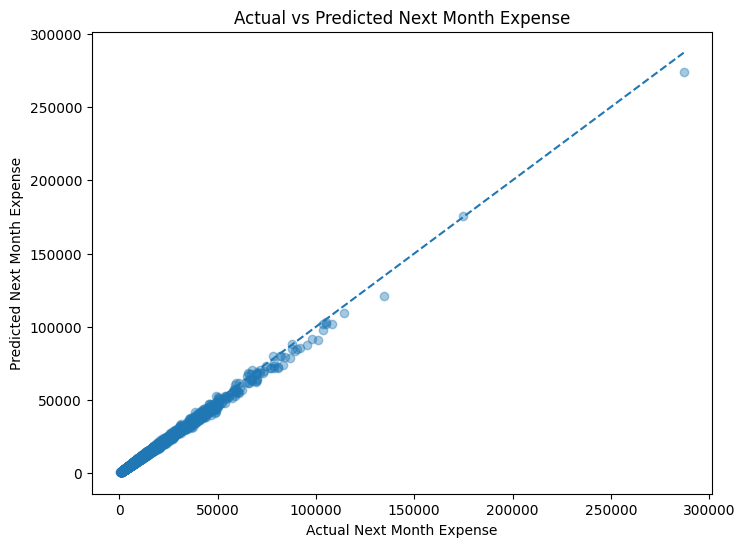

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    comparison_df["Actual_Expense"],
    comparison_df["Predicted_Expense"],
    alpha=0.4
)

min_value = min(
    comparison_df["Actual_Expense"].min(),
    comparison_df["Predicted_Expense"].min()
)

max_value = max(
    comparison_df["Actual_Expense"].max(),
    comparison_df["Predicted_Expense"].max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Next Month Expense")
plt.ylabel("Predicted Next Month Expense")
plt.title("Actual vs Predicted Next Month Expense")

plt.show()

## Step 56 - Save Final SpendWise Prediction Model

The tuned Gradient Boosting model is selected as the final SpendWise prediction model based on the validation stage.

The trained model is saved using Joblib so that the Flask backend can load it later without retraining.

The model predicts:

Next_Month_Total_Expense

which represents the user's expected expenditure for Food, Travel, and Entertainment in the following month.

In [67]:
import os
import joblib

os.makedirs("ml_artifacts", exist_ok=True)

joblib.dump(
    tuned_gradient_boosting_model,
    "ml_artifacts/final_spendwise_model.pkl"
)

print("Final SpendWise model saved successfully.")
print("Location: ml_artifacts/final_spendwise_model.pkl")

Final SpendWise model saved successfully.
Location: ml_artifacts/final_spendwise_model.pkl


# CELL 124 - LOAD THE FINAL TRAINED MODEL
## Step 57 - Load and Verify Final Model

The saved model is loaded again to verify that the backend will be able to load the trained model successfully after restarting the development environment.

In [68]:
final_model = joblib.load(
    "ml_artifacts/final_spendwise_model.pkl"
)

print("Final model loaded successfully.")
print(type(final_model))

Final model loaded successfully.
<class 'sklearn.ensemble._gb.GradientBoostingRegressor'>


# CELL 126 - DEFINE THE PREDICTION FUNCTION
## Step 58 - Backend-Ready Prediction Function

This function prepares user input in the same feature structure used during model training.

It:

1. Creates a DataFrame from the user's input.
2. Separates numerical and categorical features.
3. Applies the saved OneHotEncoder to categorical features.
4. Combines numerical and encoded features.
5. Arranges the features in the same order used during training.
6. Sends the processed data to the final trained model.
7. Returns the predicted next-month total expenditure.

This function will later be called by the Flask backend.

In [69]:
def predict_next_month_expense(user_data):
    """
    Predict next month's total Food + Travel + Entertainment expense.
    """

    # Convert input into DataFrame
    input_df = pd.DataFrame([user_data])

    # Numerical features
    numerical_data = input_df[numerical_features]

    # Categorical features
    categorical_data = input_df[categorical_features]

    # Encode categorical features
    encoded_categorical = encoder.transform(categorical_data)

    # Convert encoded features to DataFrame
    encoded_columns = encoder.get_feature_names_out(
        categorical_features
    )

    encoded_categorical_df = pd.DataFrame(
        encoded_categorical,
        columns=encoded_columns,
        index=input_df.index
    )

    # Combine numerical and categorical features
    processed_input = pd.concat(
        [
            numerical_data.reset_index(drop=True),
            encoded_categorical_df.reset_index(drop=True)
        ],
        axis=1
    )

    # Ensure exact feature order used during training
    processed_input = processed_input[X_train_processed.columns]

    # Generate prediction
    prediction = final_model.predict(processed_input)[0]

    return prediction

## Step 59 - Test Backend Prediction Function

A sample record from the test dataset is passed through the complete prediction pipeline.

This verifies that the saved preprocessing objects and final model work together correctly before integration with Flask.

In [70]:
# Take one test record
sample_input = test_df[selected_features].iloc[0].to_dict()

# Generate prediction
sample_prediction = predict_next_month_expense(sample_input)

print(f"Predicted Next Month Expense: ₹{sample_prediction:,.2f}")

Predicted Next Month Expense: ₹13,639.96


## Step 60 - Verify Sample Prediction

The predicted value is compared with the actual target value for the same test record.

This is only an individual example to verify that the prediction function is working correctly. The overall model performance should be judged using the test-set evaluation metrics calculated earlier.

In [71]:
sample_actual = y_test.iloc[0]

print(f"Actual Next Month Expense    : ₹{sample_actual:,.2f}")
print(f"Predicted Next Month Expense : ₹{sample_prediction:,.2f}")
print(
    f"Absolute Error               : "
    f"₹{abs(sample_actual - sample_prediction):,.2f}"
)

Actual Next Month Expense    : ₹13,548.49
Predicted Next Month Expense : ₹13,639.96
Absolute Error               : ₹91.47


## Step 61 - Final ML Artifacts

The following files are required by the SpendWise backend.

The final model and preprocessing objects are stored in the `ml_artifacts` folder so that Flask can load them without retraining the model.

In [72]:
import os

required_artifacts = [
    "final_spendwise_model.pkl",
    "encoder.pkl",
    "selected_features.pkl",
    "numerical_features.pkl",
    "categorical_features.pkl",
    "target_column.pkl"
]

print("SpendWise ML Artifacts")
print("-" * 40)

for artifact in required_artifacts:
    path = os.path.join("ml_artifacts", artifact)

    if os.path.exists(path):
        print(f"✓ {artifact}")
    else:
        print(f"✗ {artifact} - Missing")

SpendWise ML Artifacts
----------------------------------------
✓ final_spendwise_model.pkl
✓ encoder.pkl
✓ selected_features.pkl
✓ numerical_features.pkl
✓ categorical_features.pkl
✓ target_column.pkl
